Generating Monthly Chart...


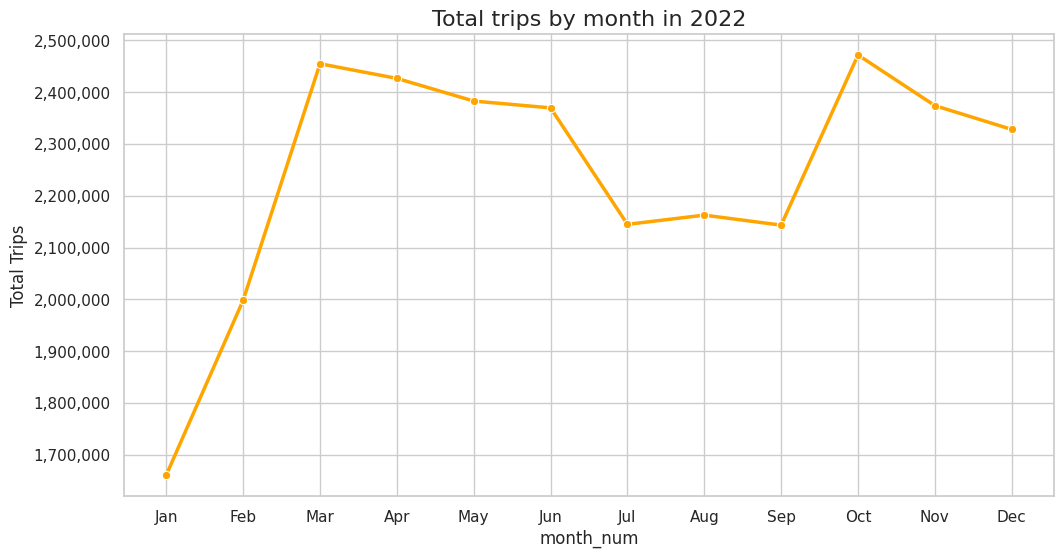

Generating DOW Duration Chart...


/tmp/ipykernel_22277/2461880976.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_dow, x='Day_of_Week', y='p95_trip_duration', palette='viridis', edgecolor='black')


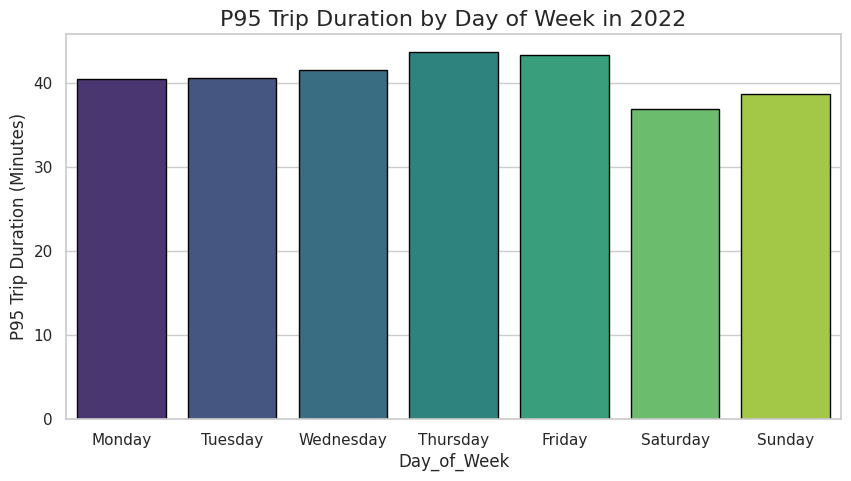

Generating Speed Chart...


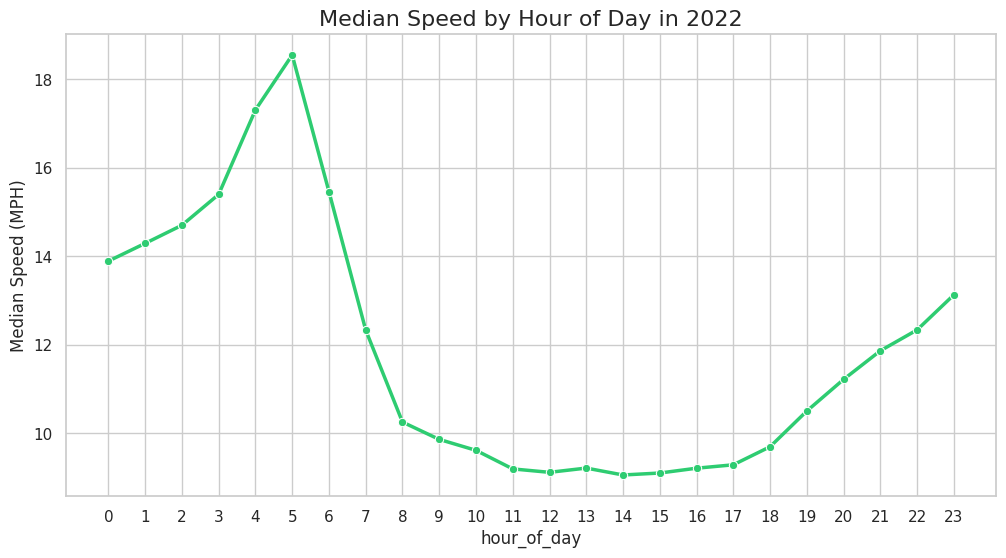

Generating Zones Chart...


/tmp/ipykernel_22277/2461880976.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='trip_count', y='pickup_zone', data=top_zones, palette='magma')


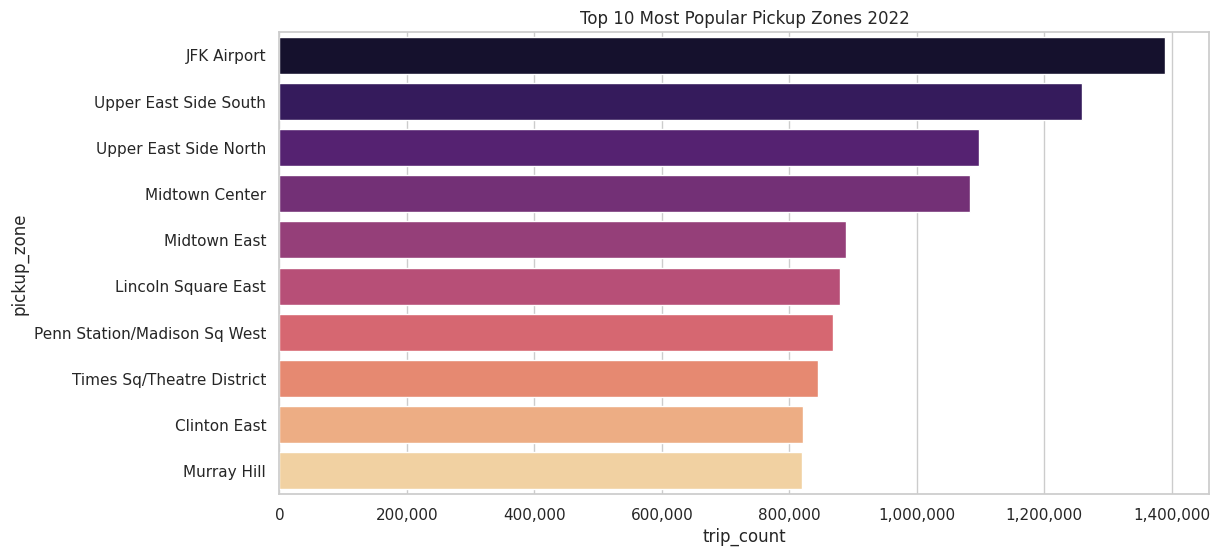

Generating Heatmap...


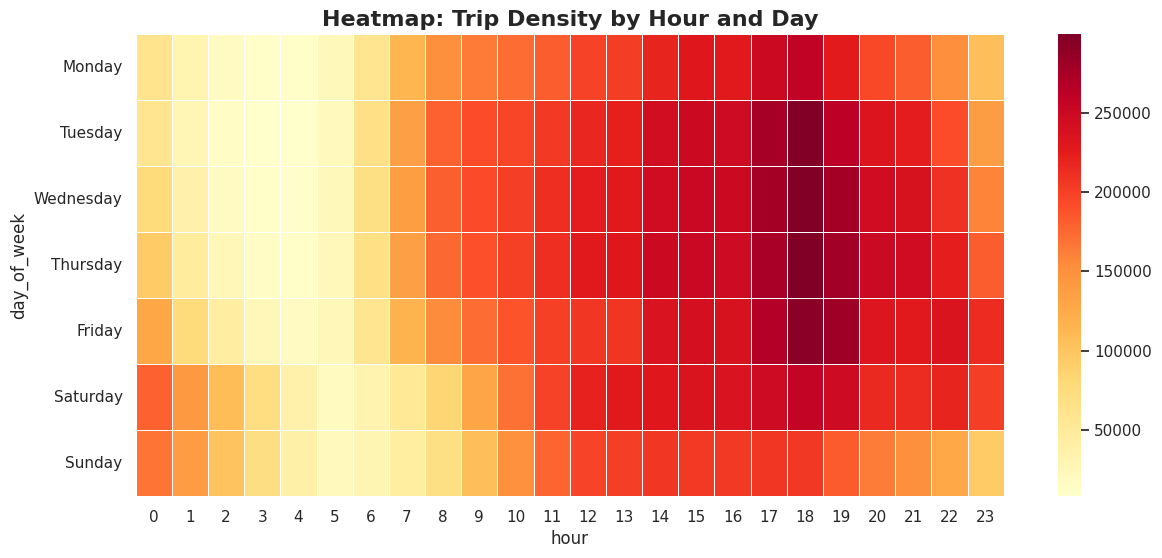

In [1]:
# --- 5_visualization.ipynb ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from pathlib import Path

sns.set_theme(style="whitegrid")
PROCESSED_DIR = Path('../processed')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# CHART 1: Total Trips by Month
# Source: Step 3 (kpi_monthly_2022.csv)
# ==========================================
print("Generating Monthly Chart...")
try:
    # We use the file from Step 3 directly
    kpi_monthly = pd.read_csv(PROCESSED_DIR / 'kpi_monthly_2022.csv')
    kpi_monthly['tpep_pickup_datetime'] = pd.to_datetime(kpi_monthly['tpep_pickup_datetime'])
    kpi_monthly['month_num'] = kpi_monthly['tpep_pickup_datetime'].dt.month
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=kpi_monthly, x='month_num', y='total_trips', marker='o', linewidth=2.5, color='orange')
    
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.title('Total trips by month in 2022', fontsize=16)
    plt.ylabel('Total Trips')
    plt.savefig(FIGURES_DIR / 'total_trips_by_month_2022.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not generate Chart 1: {e}")

# ==========================================
# CHART 2: P95 Duration by Day of Week
# Source: Step 4 (kpi_granular_dow_duration.csv)
# ==========================================
print("Generating DOW Duration Chart...")
try:
    kpi_dow = pd.read_csv(PROCESSED_DIR / 'kpi_granular_dow_duration.csv')
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=kpi_dow, x='Day_of_Week', y='p95_trip_duration', palette='viridis', edgecolor='black')
    
    plt.title('P95 Trip Duration by Day of Week in 2022', fontsize=16)
    plt.ylabel('P95 Trip Duration (Minutes)')
    plt.savefig(FIGURES_DIR / 'p95_trip_duration_by_dow_2022.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not generate Chart 2: {e}")

# ==========================================
# CHART 3: Average Speed by Hour
# Source: Step 4 (kpi_granular_speed_hour.csv)
# ==========================================
print("Generating Speed Chart...")
try:
    kpi_speed = pd.read_csv(PROCESSED_DIR / 'kpi_granular_speed_hour.csv')
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=kpi_speed, x='hour_of_day', y='p50_speed_mph', marker='o', linewidth=2.5, color='#2ecc71')
    
    plt.title('Median Speed by Hour of Day in 2022', fontsize=16)
    plt.xticks(range(0, 24))
    plt.ylabel('Median Speed (MPH)')
    plt.savefig(FIGURES_DIR / 'average_speed_by_hour_2022.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not generate Chart 3: {e}")

# ==========================================
# CHART 4: Top 10 Pickup Zones
# Source: Step 4 (kpi_granular_top_zones.csv)
# ==========================================
print("Generating Zones Chart...")
try:
    top_zones = pd.read_csv(PROCESSED_DIR / 'kpi_granular_top_zones.csv')
    
    plt.figure(figsize=(12,6))
    sns.barplot(x='trip_count', y='pickup_zone', data=top_zones, palette='magma')
    
    plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.title('Top 10 Most Popular Pickup Zones 2022')
    plt.savefig(FIGURES_DIR / 'top10_zones_2022.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not generate Chart 4: {e}")

# ==========================================
# CHART 5: Heatmap
# Source: Step 4 (kpi_granular_heatmap.csv)
# ==========================================
print("Generating Heatmap...")
try:
    heatmap_raw = pd.read_csv(PROCESSED_DIR / 'kpi_granular_heatmap.csv')
    
    # Pivot for heatmap format
    heatmap_data = heatmap_raw.pivot(index='day_of_week', columns='hour', values='trip_count')
    
    # Reindex for correct weekday order
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    heatmap_data = heatmap_data.reindex(weekday_order)
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
    plt.title('Heatmap: Trip Density by Hour and Day', fontsize=16, fontweight='bold')
    plt.savefig(FIGURES_DIR / 'hour_weekday_heatmap.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not generate Chart 5: {e}")